<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


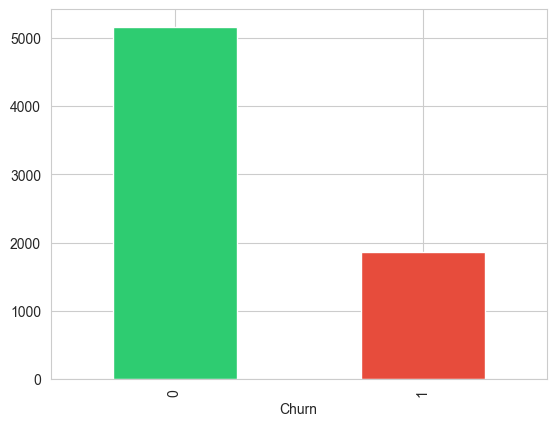

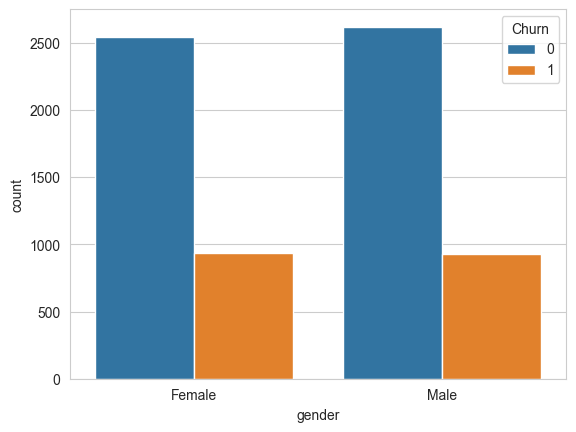

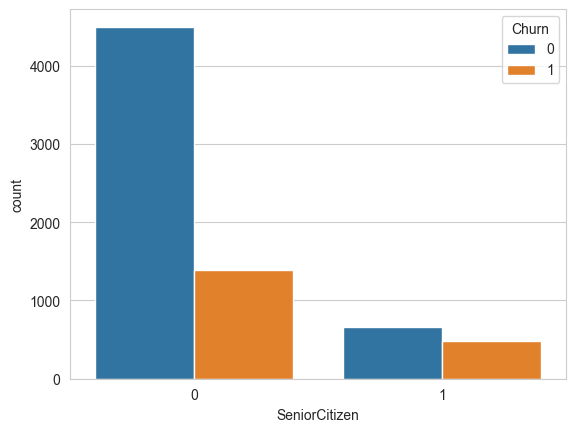

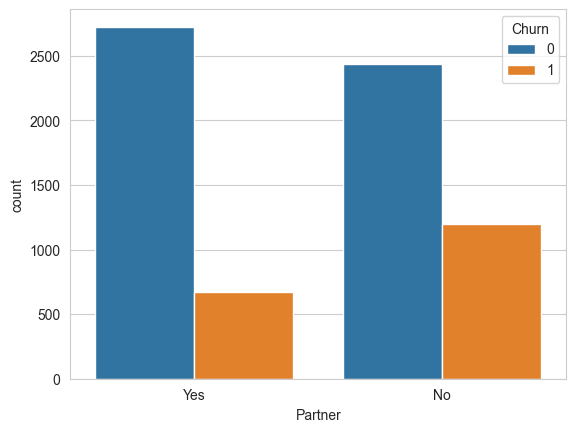

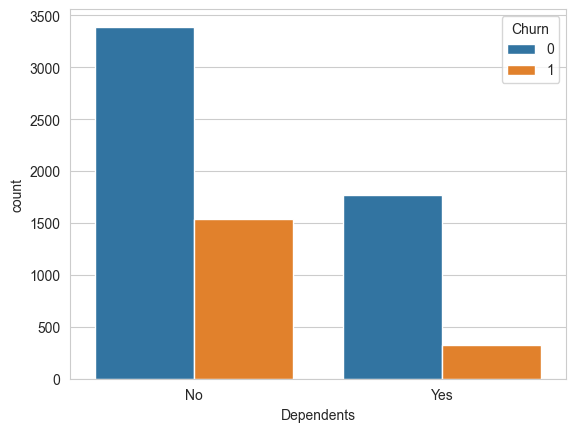

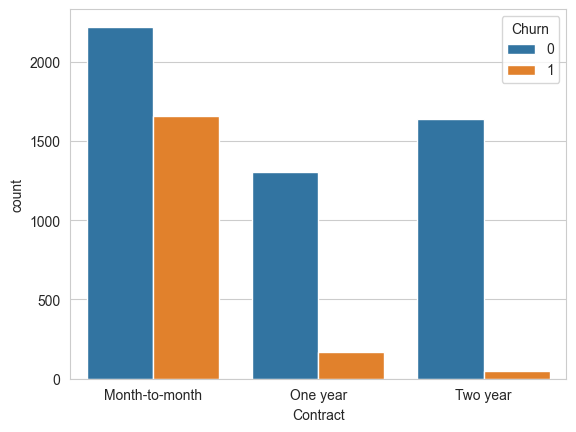

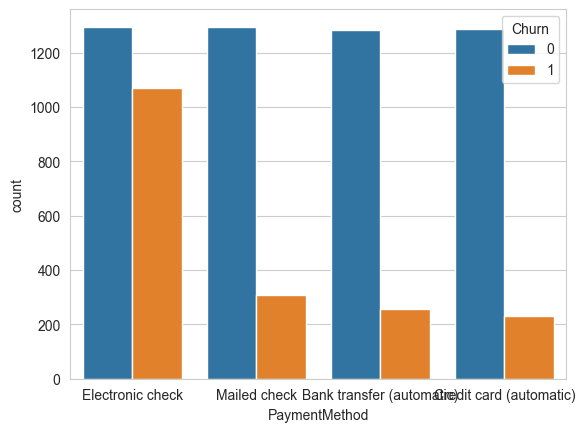

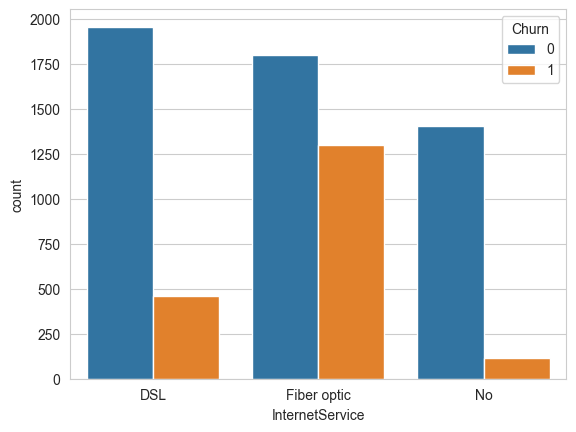

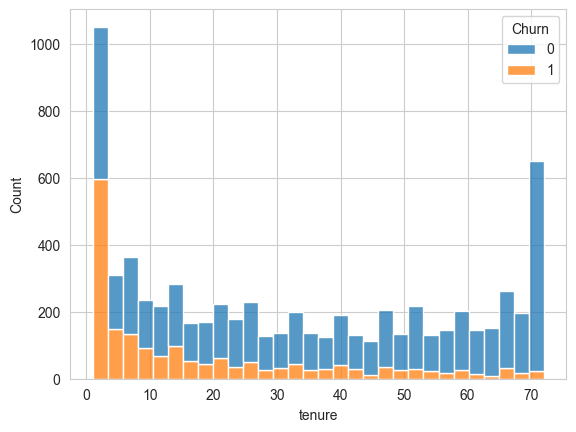

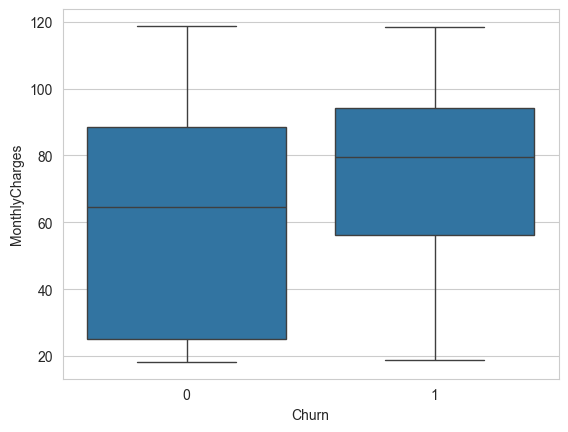

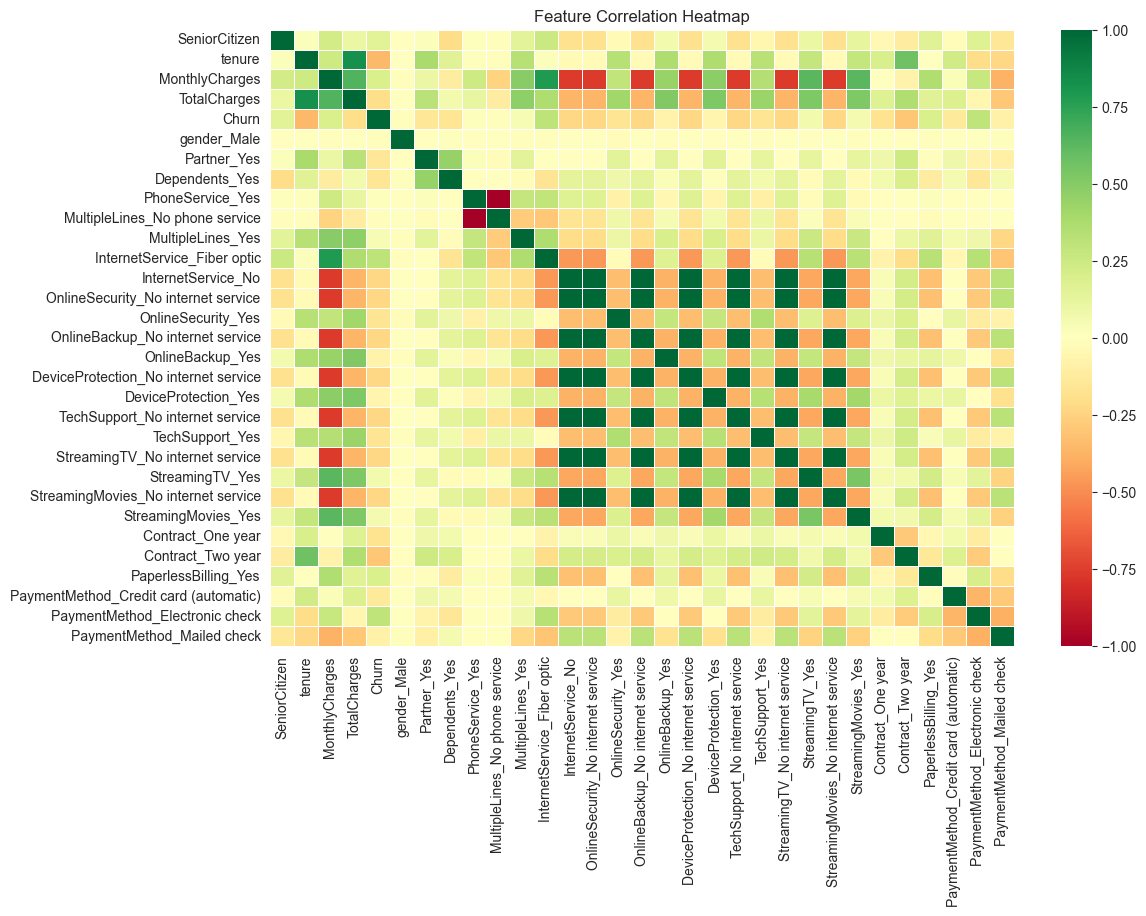

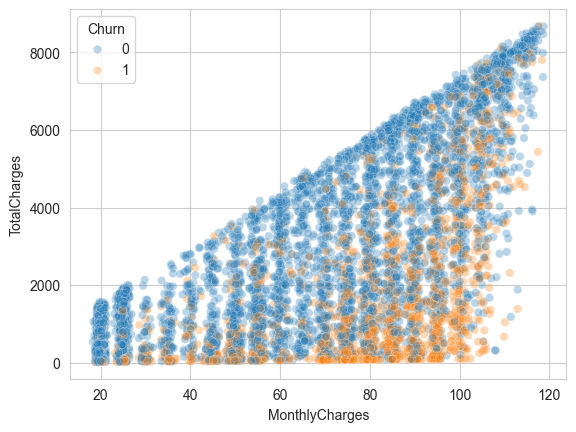

Accuracy: 0.7889
              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1033
           1       0.62      0.52      0.57       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407

ROC-AUC: 0.8319


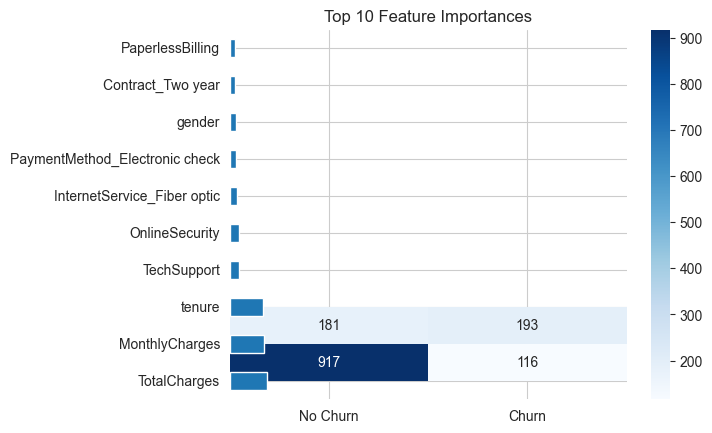

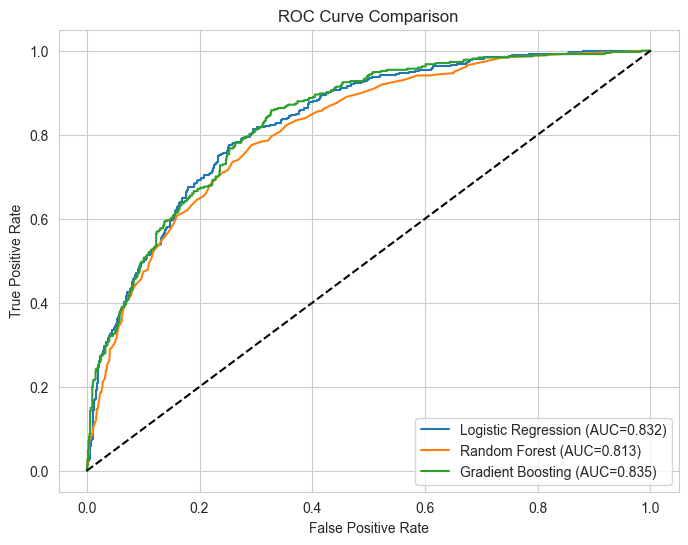

2
Model       Gradient Boost
Accuracy          0.793177
ROC-AUC           0.834592
Name: 2, dtype: object


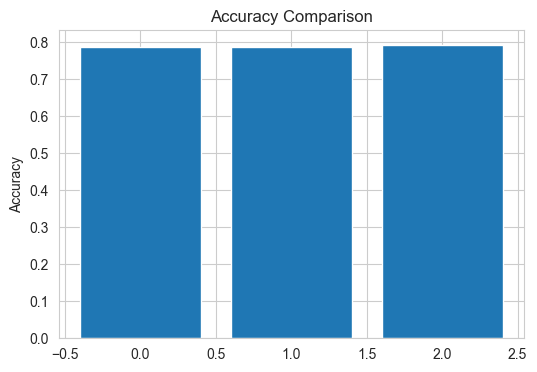

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv('Customer-Churn.csv')
df.head()
df.shape
df.info()
df['Churn'].value_counts()
df.isnull().sum()

df['TotalCharges']=pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(inplace=True)
df.drop('customerID',axis=1,inplace=True)
df['Churn']=df['Churn'].map({'Yes': 1,'No': 0})
c=df.select_dtypes(include='object').columns.tolist()
print(c)
sns.set_style("whitegrid")
plt.show()
df['Churn'].value_counts().plot(kind='bar',color=['#2ecc71','#e74c3c'])
plt.show()
sns.countplot(x='gender',hue='Churn',data=df)
plt.show()
sns.countplot(x='SeniorCitizen',hue='Churn',data=df)
plt.show()
sns.countplot(x='Partner',hue='Churn',data=df)
plt.show()
sns.countplot(x='Dependents',hue='Churn',data=df)
plt.show()
sns.countplot(x='Contract',hue='Churn',data=df)
plt.show()
sns.countplot(x='PaymentMethod',hue='Churn',data=df)
plt.show()
sns.countplot(x='InternetService',hue='Churn',data=df)
plt.show()
sns.histplot(data=df,x='tenure',hue='Churn',multiple='stack',bins=30)
plt.show()
sns.boxplot(x='Churn',y='MonthlyCharges',data=df)
plt.show()
df_enc=pd.get_dummies(df,drop_first=True)
plt.figure(figsize=(12,8))
sns.heatmap(df_enc.corr(),cmap='RdYlGn',linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()
sns.scatterplot(x='MonthlyCharges',y='TotalCharges',hue='Churn',data=df,alpha=0.3)
plt.show()

from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
binary_cols=['gender','Partner','Dependents','PhoneService','PaperlessBilling','MultipleLines','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies']
for col in binary_cols: 
    df[col]=le.fit_transform(df[col])
df=pd.get_dummies(df,columns=['InternetService','Contract','PaymentMethod'],drop_first=True)
X=df.drop('Churn',axis=1)
y=df['Churn']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
from sklearn.preprocessing import StandardScaler; 
sc=StandardScaler()
X_train=sc.fit_transform(X_train); 
X_test=sc.transform(X_test)
import joblib; 
joblib.dump(sc,'scaler.pkl')
import json; 
json.dump(list(X.columns),open('columns.json','w'))
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression(max_iter=1000,random_state=42)
lr.fit(X_train, y_train)
y_pred_lr=lr.predict(X_test)
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
print(f"Accuracy: {accuracy_score(y_test,y_pred_lr):.4f}")
print(classification_report(y_test,y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test,lr.predict_proba(X_test)[:,1]):.4f}")
cm=confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=['No Churn','Churn'],yticklabels=['No Churn','Churn'])
plt.title('Logistic Regression Confusion Matrix')
joblib.dump(lr,'lr_model.pkl')
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1)
rf.fit(X_train,y_train)
y_pred_rf=rf.predict(X_test)
import pandas as pd
importances=pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)[:10]
importances.plot(kind='barh'); 
plt.title('Top 10 Feature Importances')
joblib.dump(rf,'rf_model.pkl')
from sklearn.ensemble import GradientBoostingClassifier
gb=GradientBoostingClassifier(n_estimators=100,random_state=42)
gb.fit(X_train,y_train)
y_pred_gb=gb.predict(X_test)
results=pd.DataFrame({
    'Model':['Logistic Reg','Random Forest','Gradient Boost'],
    'Accuracy':[accuracy_score(y_test,y_pred_lr),
                accuracy_score(y_test,y_pred_rf),
                accuracy_score(y_test,y_pred_gb)],
    'ROC-AUC':[roc_auc_score(y_test,lr.predict_proba(X_test)[:,1]),
               roc_auc_score(y_test,rf.predict_proba(X_test)[:,1]),
               roc_auc_score(y_test,gb.predict_proba(X_test)[:,1])]
})
results.set_index('Model').round(4)
lr_prob=lr.predict_proba(X_test)[:,1]
rf_prob=rf.predict_proba(X_test)[:,1]
gb_prob=gb.predict_proba(X_test)[:,1]
from sklearn.metrics import roc_curve
lr_fpr,lr_tpr,_=roc_curve(y_test,lr_prob)
rf_fpr,rf_tpr,_=roc_curve(y_test,rf_prob)
gb_fpr,gb_tpr,_=roc_curve(y_test,gb_prob)
plt.figure(figsize=(8,6))
plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC={roc_auc_score(y_test,lr_prob):.3f})"
)
plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC={roc_auc_score(y_test,rf_prob):.3f})"
)
plt.plot(
    gb_fpr,
    gb_tpr,
    label=f"Gradient Boosting (AUC={roc_auc_score(y_test,gb_prob):.3f})"
)
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()
best_model=results["Accuracy"].idxmax()
print(best_model)
print(results.loc[best_model])
plt.figure(figsize=(6,4))
plt.bar(results.index, results["Accuracy"])
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()
